# 以下内容来自 Part I: Tricks or Traps? A Deep Dive into RL for LLM Reasoning

## 优势归一化是稳定策略梯度训练的常用技术，但具体如何实现却众说纷纭。
- 核心争议点在于：应该在“组内（group-level）”还是“批次内（batch-level）”进行归一化？
- 以及，归一化时是否必须使用标准差（standard deviation）？

### 优势归一化对奖励机制的敏感性
- <b>组级别归一化</b>在各种奖励设置下都表现出鲁棒的效率。
- <b>批次级别归一化</b>在大学习率设置下提供更稳定的改进。

#### 比较了三种设置：无归一化、批次级别归一化和组级别归一化。

##### 默认奖励设置（）：即答案正确奖励为1，错误为0。

- 结果显示，在4B和8B模型上，组级别归一化都表现出了最稳定的训练动态和最高的最终性能。
- 相比之下，批次级别归一化对奖励分布的偏斜非常敏感。当一个批次中大部分样本奖励相同（例如大部分都错误），少数几个异常样本（例如一两个正确答案）会主导优势的计算，导致性能崩溃。

#### 更大范围的奖励设置（）：将错误答案的奖励从0变为-1，增大了奖励的区分度。

- 有趣的是，在这种设置下，批次级别归一化的性能得到了显著的恢复和提升

#### 这个实验有力地证明了优势归一化技术对奖励机制的敏感性。
- 组级别归一化因为它只在prompt内部进行比较，所以更加鲁棒。
- 而批次级别归一化虽然在奖励信号强且分布均衡时可能有效，但在稀疏奖励下风险很高。

### 标准差项在归一化中的作用
- 当奖励分布高度集中时（例如，在简单的训练数据上），移除标准差项可以增强模型训练的稳定性和有效性。

#### 上一个实验引发了一个新问题：是什么导致了这种敏感性？一个合理的猜测是标准差项。
- 当一个组或一个批次内的响应奖励高度相似时（例如，在简单任务上，模型很快学会全部答对），标准差会变得非常小。
- 此时，用一个极小的标准差去做除法，会导致归一化后的优势值被过度放大，引起梯度爆炸，破坏训练稳定性。这类似于Dr. GRPO论文中提到的“难度偏差（difficulty bias）”现象。

#### 在简单数据上：
- 训练初期，奖励的标准差迅速下降到一个很低的水平。
- 此时，移除标准差的归一化方法（仅减去均值）表现出了明显更优的性能和稳定性。
- 而包含标准差的方法，由于优势被放大，训练过程非常不稳定。
#### 在困难数据上：
- 奖励的标准差在整个训练过程中都维持在较高水平。
- 此时，两种归一化方法（包含或不含标准差）的性能差异不大，训练都比较稳定。

##### 这个实验清晰地揭示了标准差项在归一化中的关键作用，并给出了明确的实践指导：在任务简单、奖励信号集中的场景下，考虑去掉标准差项，只做中心化处理，可能会获得更稳定的训练效果。

### 重构一个鲁棒的归一化技术
- 在局部（组）级别计算均值，并在全局（批次）级别计算标准差，可以实现更鲁棒的奖励重塑。

综合前两个实验的结论，作者提出了一个最终的问题：是否存在一种更鲁棒、更有效的均值和标准差组合方式？他们尝试了两种计算标准差的方法，都搭配稳定的组级别均值：
- 局部标准差（Local std）：即标准的组级别归一化。
- 全局标准差（Global std）：均值在组内计算，但标准差在整个批次上计算。

#### 实验结果（如下图7所示）明确显示，全局标准差（Global std）的方法表现出了明显的优势。
- 作者认为，这是因为批次级别的标准差提供了更强的归一化效果，有效减小了梯度的大小，从而防止了策略的过度更新。
- 这种方法更适应稀疏奖励和粗粒度优势拟合的场景，带来了更稳定和鲁棒的学习行为。

这一发现与Hu等人（2025）的观点不谋而合，即批次级别的归一化，或者在某些场景下“减去局部均值，除以全局标准差”，是一种更优的实践。

In [1]:
import numpy as np

# 同一个问题的4个答案的奖励
rewards = [1.0,0.5,0.0,0.0] # 组内奖励

# group-level的归一化
advantages = [(r - np.mean(rewards)) / np.std(rewards) for r in rewards]
print(advantages)

[1.507556722888818, 0.30151134457776363, -0.9045340337332909, -0.9045340337332909]


### batch-level的归一化

In [ ]:
# PPO 中的 GAE 优势计算 + Batch-level 归一化
advantages = []
gae = 0.0
for t in reversed(range(len(rewards))):
    delta = rewards[t] + gamma * values[t+1] - values[t]
    gae = delta + gamma * lam * gae
    advantages.insert(0, gae)

# Batch-level 归一化（通常在 mini-batch 上进行）
advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

### 先group-level的归一化，然后batch-level的归一化

In [ ]:
# Step 1: Group-level 归一化（每个 reward 函数单独处理）
for i in range(num_reward_functions):
    reward_i = rewards[:, i]
    mean_grouped = reward_i.view(-1, num_generations).mean(dim=1)
    std_grouped = reward_i.view(-1, num_generations).std(dim=1)
    
    # 扩展到原始维度
    mean_grouped = mean_grouped.repeat_interleave(num_generations, dim=0)
    std_grouped = std_grouped.repeat_interleave(num_generations, dim=0)
    
    # Group-level 优势
    advantage_group = (reward_i - mean_grouped) / (std_grouped + 1e-4)

# Step 2: Batch-level 归一化
bn_mean = advantages.mean()
bn_std = advantages.std()
advantages = (advantages - bn_mean) / (bn_std + 1e-4)

In [ ]:
┌─────────────────────────────────────────────────────────┐
│                    输入: rewards_per_func                │
│              形状: [batch_size, num_reward_funcs]       │
│              来自多奖励模型的原始奖励                     │
└─────────────────────────────────────────────────────────┘
                           ↓
┌─────────────────────────────────────────────────────────┐
│  Step 1: Group-level Normalization (每个奖励函数独立)    │
│  - 按 prompt 分组 (每组 num_generations 个回答)         │
│  - 组内计算 mean/std                                    │
│  - 输出: combined_reward_advantage                      │
└─────────────────────────────────────────────────────────┘
                           ↓
┌─────────────────────────────────────────────────────────┐
│  Step 2: Batch-level Normalization (全局归一化)          │
│  - 加权融合多奖励优势                                   │
│  - 全局计算 mean/std                                    │
│  - 输出: advantages (最终用于策略梯度)                  │
└─────────────────────────────────────────────────────────┘

In [ ]:
# GDPO官网实现

# 多进程收集: 从所有GPU进程收集奖励数据
rewards_per_func = gather(rewards_per_func)

# 将可能出现的NaN值替换为0，避免后续计算崩溃
rewards_per_func_filter = torch.nan_to_num(rewards_per_func)

all_reward_advantage []
# group-level归一化
for i in range(len(self.reward_weights)): # 遍历每个奖励函数
    reward_i = rewards_per_func_filter[:i] # 提取第i个奖励函数的奖励
    each_reward_mean_grouped = reward_i.view(-1,self.num_generations).mean(dim=1)
    each_reward_std_grouped = reward_i.view(-1,self.num_generations).std(dim=1)
    
    # 扩展到原始维度：repeat_interleave
    each_reward_mean_grouped = each_reward_mean_grouped.repeat_interleave(self.num_generations,dim=0)
    each_reward_std_grouped = each_reard_std_grouped.repeat_interleave(self.num_generations,dim=0)
    
    # 计算group-level的优势
    each_reward_advantage = reward_i - each_reward_mean_grouped 
    each_reward_advantage = each_reward_advantage / (each_reward_std_grouped + 1e-4)
    
    # 多奖励融合
    all_reward_advantage.append(each_reward_advantage)
    

combined_reward_advantage = torch.stack(all_reward_advantage,dim=1)
# reward_weights 不同的奖励占据的权重不同如 [0.5,0.2,0.3]
pre_bn_advantages = (combined_reward_advantage * self.reward_weights.to(device).unsqueeze(0)).nansum(dim=1)

# 2 batch-level的归一化: 在真个batch内再次标准化
bn_advantages_mean = pre_bn_advantages.mean() # 全局均值
bn_advantages_std = pre_bn_advantages.std() # 全局标准差

advantages = (pre_bn_advantages - bn_advantages_mean)/(bn_advantages_std + 1e-4)

## 裁剪 (Clipping)：探索与稳定的平衡艺术

PPO中的裁剪机制是保证训练稳定的核心，但它也可能带来一个严重问题：熵坍塌（entropy collapse）。它会过度抑制低概率令牌（token）的探索，导致模型的生成策略变得单一和确定性，缺乏多样性。这在需要创新性思维的复杂推理任务中是致命的。

为了解决这个问题，DAPO等工作引入了Clip-Higher机制，即放宽PPO裁剪范围的上限（1+ epsilon_higher），给低概率、但可能带来高回报的token更大的探索空间

然而，这个 epsilon_higher 该如何设置？在什么场景下应该使用Clip-Higher？这些问题一直缺乏深入分析。

### Clip-Higher的适用场景
#### 对于基础推理能力更强的模型（如Aligned模型），提高裁剪上限参数更可能促进对更优解路径的探索。
<b>作者通过实验发现，Clip-Higher的效果是模型依赖（model-dependent）的。</b>

- <b>对于Base模型</b>：提高裁剪上限几乎没有带来熵的改善，甚至损害了最终性能。这是因为Base模型本身的策略表达能力有限，策略更新的偏离度很小（clipping rate ≈ 0.003），即使放宽上限，它也难以探索到新的高奖励路径。

- <b>对于Aligned模型：</b>结果截然不同。提高裁剪上限显著减缓了熵的下降速度，并带来了下游评估指标的持续提升。

In [1]:
from IPython.display import Image

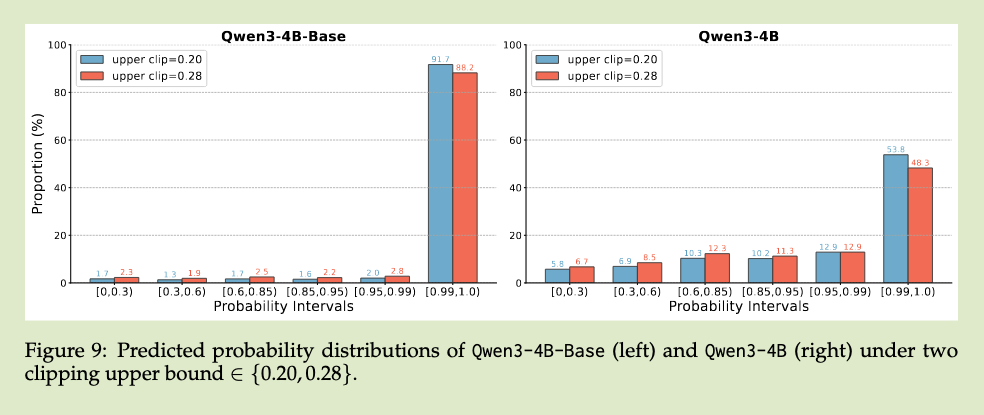

In [2]:
Image(filename='./image/base_align.png',width=600)

### 从语言学角度分析Clip-Higher的有效性

#### 传统裁剪可能限制模型生成创新性推理结构的能力。Clip-Higher允许模型探索更广泛的话语推理结构

为了更深入地理解Clip-Higher的机制，作者从令牌级别的语言学角度进行了分析。

- 当裁剪上限较低时（如传统的0.2），被裁剪得最频繁的往往是连接性词汇，如 "therefore", "if", "but" 等。这些词汇通常出现在句首，标志着推理方向的转变。PPO的优化机制会积极地抑制这些引入新方向的词汇，以保证稳定性，但这也限制了模型生成多样化论证结构的能力。

- 当裁剪上限提高到0.28时，被裁剪的重点从连接词转向了高频的功能性词汇，如 "is", "the", "a" 等。这些词汇在句子中普遍存在，上下文依赖性较弱，其概率估计对新旧策略的差异更敏感。

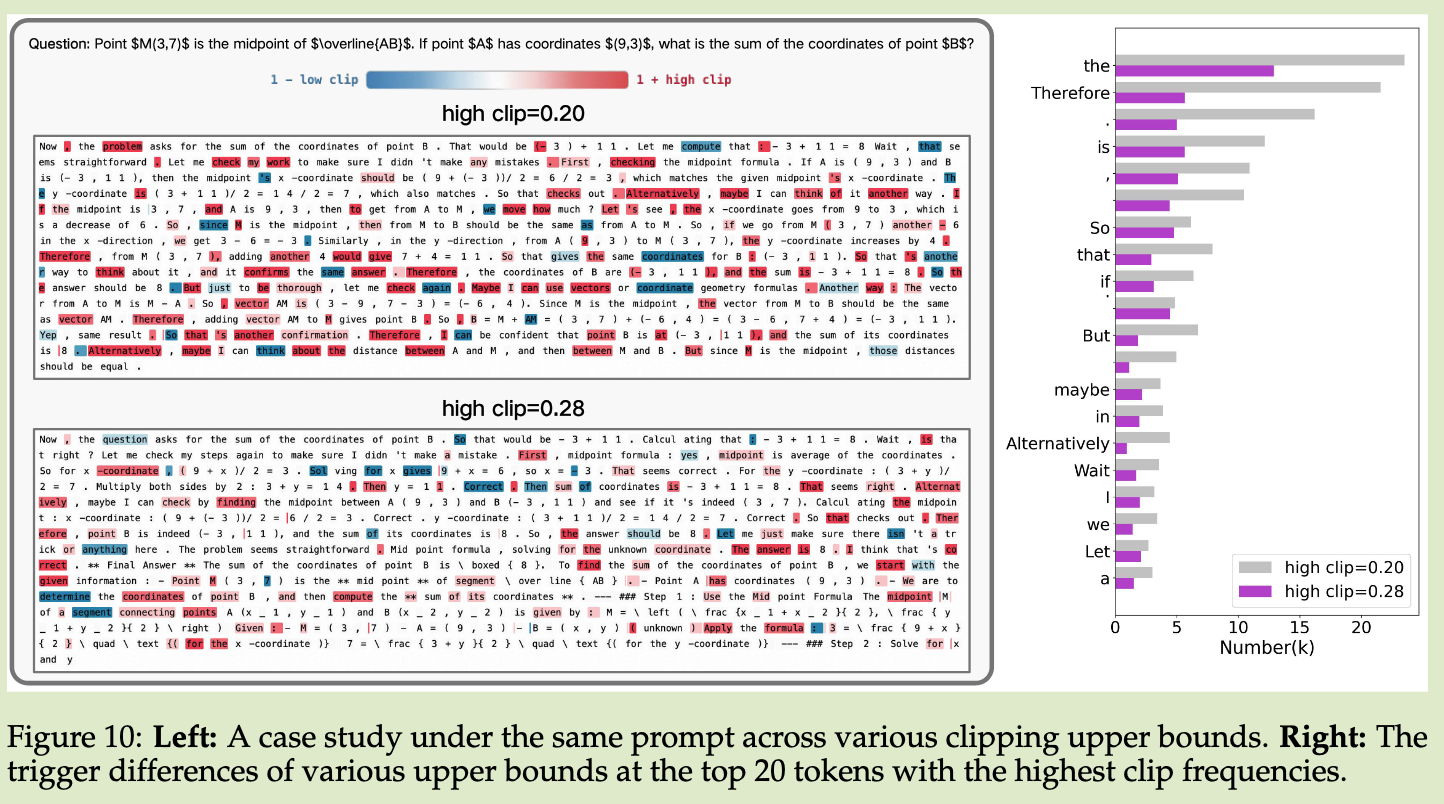

In [3]:
Image(filename='./image/high_clip.png',width=600)

<b>这种转变允许模型在话语结构层面（discourse level）进行更广泛的探索，生成更多样的推理路径，而对核心句子结构的稳定性影响较小。</b>

### 如何设置优势裁剪的上限？
#### 在小尺寸模型上，性能与裁剪上限之间似乎存在一种“缩放定律（scaling law）”，但在大模型上则不然。

既然Clip-Higher有效，那么上限值（）到底设为多少最合适呢？目前大多数工作都直接沿用了DAPO中0.28的默认值。作者认为，不同模型对此参数的偏好应该不同。

为此，他们进行了一系列超参数搜索实验，在0.2到0.32的范围内探索裁剪上限。

- 对于小模型（4B）：随着裁剪上限的增加，模型性能也随之逐步提升，在0.32时达到最佳。这呈现出一种清晰的“缩放定律”。

- 对于大模型（8B）：性能的提升并非单调的。当上限设置为0.28时，性能最为突出，而继续增大上限反而可能导致性能下降。

#### 这个发现为从业者提供了宝贵的实践建议：对于小模型，可以大胆尝试更高的裁剪上限；而对于大模型，0.28可能是一个更优的甜点值（sweet spot）

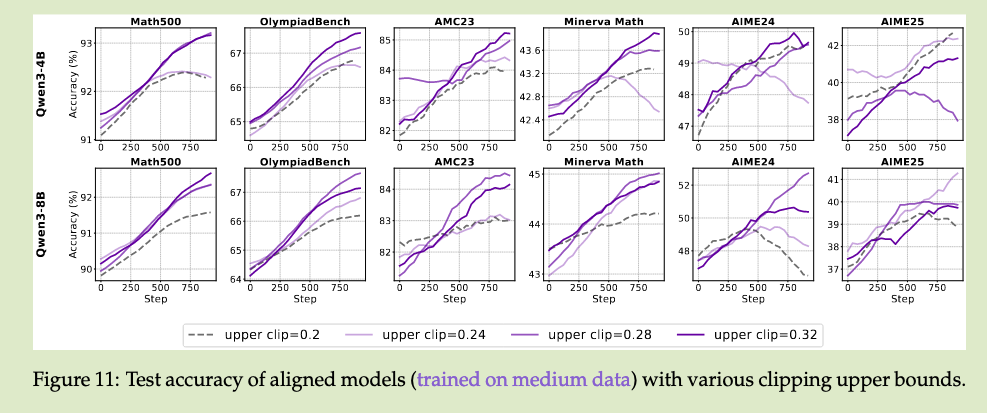

In [4]:
Image(filename='./image/clip_0.28.png',width=600)